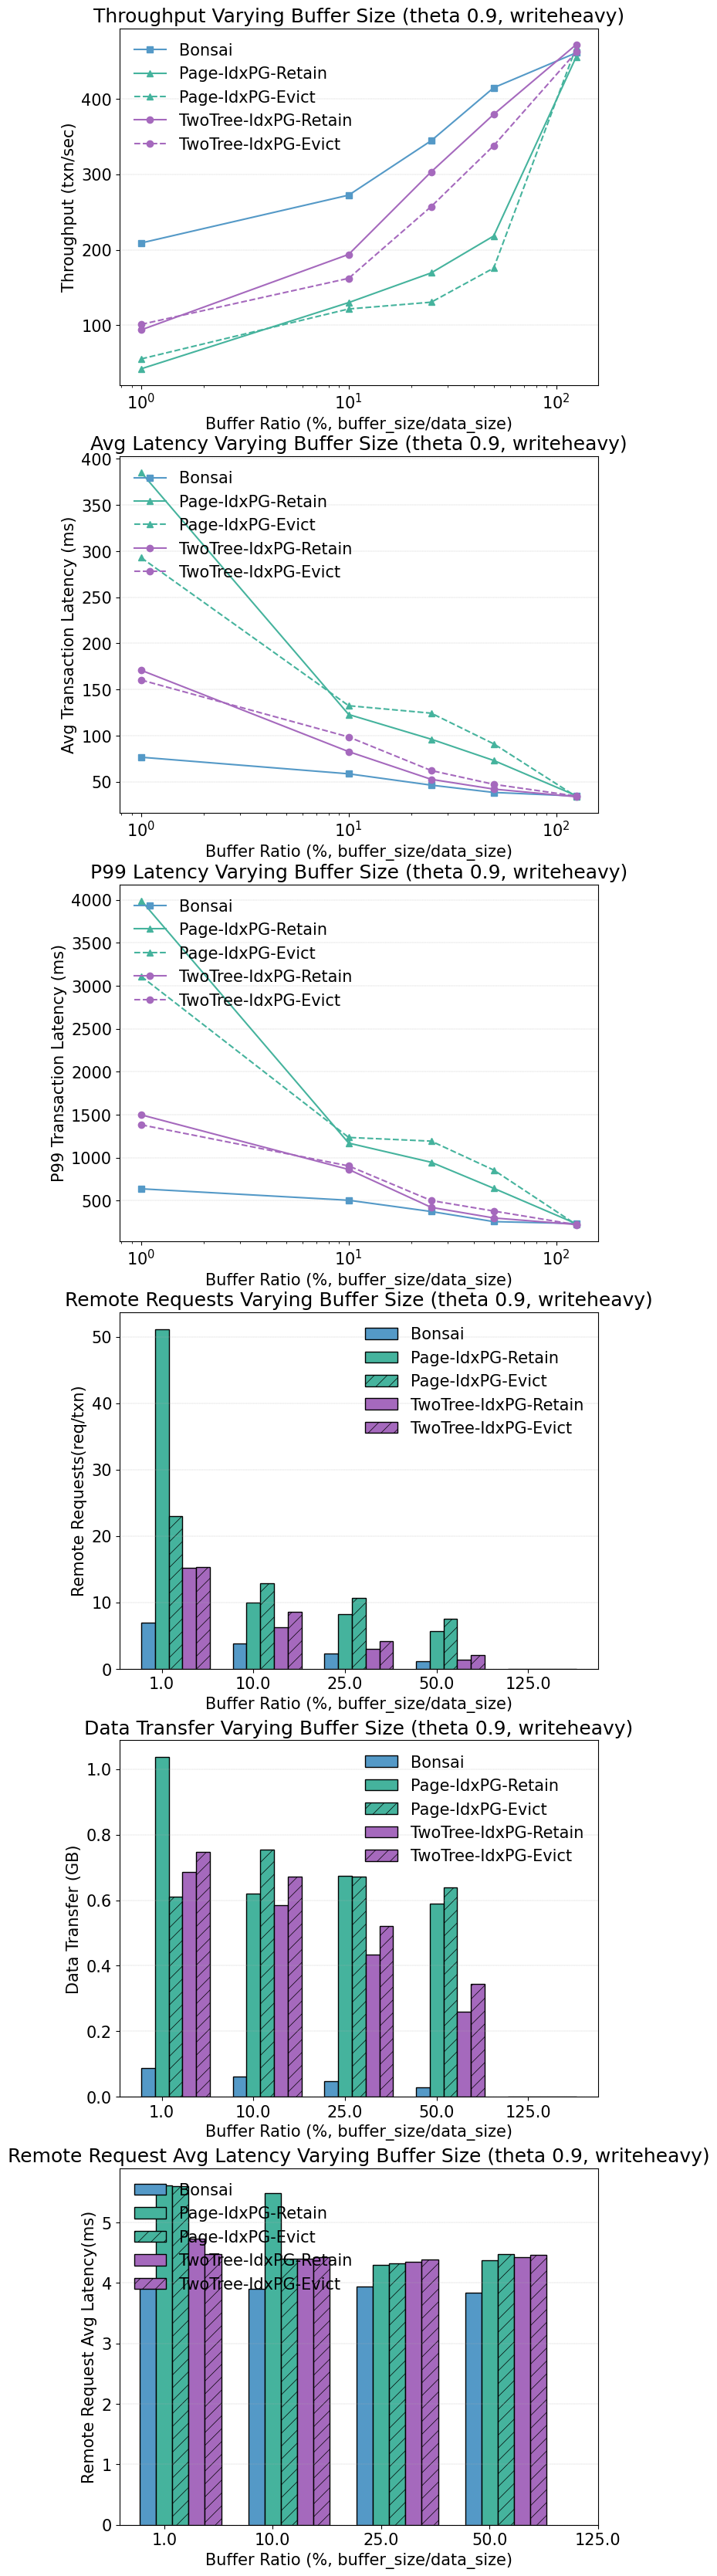

In [8]:
from process_helper import *
import numpy as np

# _, grad_colors = display_colors()
# _, bar_colors = select_color_idx(4)
color_indices, line_colors = select_color_idx(4)

plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5
idxs = ["g_total_buf_sz", "read_perc_","g_total_buf_sz"]
datadir = "../output/"
# exp_page = "debug_exp_point_10g_page_fanout250"
exp_page = "exp_point_10g_page_varybuf_rw"
exp_page_idx_evict = "exp_point_10g_page_varybuf_idx_evict_rw"
exp_tuple = "exp_point_10g_tuple_varybuf_rw"
# exp_remote = "different_settings/" + "microbench_zipf_10g_fanout18.out"
exp_twotree = "exp_point_10g_twotree_varybuf_rw"
exp_twotree_idx_evict = "exp_point_10g_twotree_varybuf_idx_evict_rw"

data_page = [json.loads(line) for line in open(datadir + exp_page + ".txt")]
df_page = pd.DataFrame().from_records(data_page)
df_page = df_page.sort_values(by='g_total_buf_sz')


data_page_idx_evict = [json.loads(line) for line in open(datadir + exp_page_idx_evict + ".txt")]
df_page_idx_evict = pd.DataFrame().from_records(data_page_idx_evict)
df_page_idx_evict = df_page_idx_evict.sort_values(by='g_total_buf_sz')


data_tuple = [json.loads(line) for line in open(datadir + exp_tuple + ".txt")]
df_tuple = pd.DataFrame().from_records(data_tuple)
df_tuple = df_tuple.sort_values(by='g_total_buf_sz')

# data_remote = [json.loads(line) for line in open(datadir + exp_remote)]
# df_remote = pd.DataFrame().from_records(data_remote)
# df_remote = apply_mask(df_remote, [
#     ["g_buf_type", ["eq", "NOBUF"]]
# ])

data_tt = [json.loads(line) for line in open(datadir + exp_twotree + ".txt")]
df_tt = pd.DataFrame().from_records(data_tt)
df_tt = df_tt.sort_values(by='g_total_buf_sz')


data_tt_idx_evict = [json.loads(line) for line in open(datadir + exp_twotree_idx_evict + ".txt")]
df_tt_idx_evict = pd.DataFrame().from_records(data_tt_idx_evict)
df_tt_idx_evict = df_tt_idx_evict.sort_values(by='g_total_buf_sz')


# print(df_tuple)
fig = plt.figure(figsize=(8, 42))

# fig, ax = plt.subplots()
ax = fig.add_subplot(6, 1, 1)


ax.plot(df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_tuple["throughput_txn_per_sec"],
        color=line_colors["BLUE"],
        marker="s", label="Bonsai")


ax.plot(df_page["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_page["throughput_txn_per_sec"],
        color=line_colors["GREEN"],
        marker="^", label="Page-IdxPG-Retain")

# # # Annotate each data point with its corresponding value
# # for i in range(len(df_page["g_total_buf_sz"])):
# #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_page_idx_evict["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_page_idx_evict["throughput_txn_per_sec"],
        color=line_colors["GREEN"],
        marker="^", label="Page-IdxPG-Evict", linestyle='dashed')
# print(df_page["throughput_txn_per_sec"])
# # Annotate each data point with its corresponding value
# for i in range(len(df_page_idx_evict["g_total_buf_sz"])):
#     plt.annotate(f'{df_page_idx_evict["throughput_txn_per_sec"][i]:.2f}', (df_page_idx_evict["g_total_buf_sz"][i], df_page_idx_evict["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

    #     ax.plot(xval, 
    #             plot_data3.loc[y]["throughput_txn_per_sec"],
    #             color=line_colors["ORANGE"],
    #             marker=".", label="Remote-Index")

ax.plot(df_tt["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_tt["throughput_txn_per_sec"],
        color=line_colors["PURPLE"],
        marker="o", label="TwoTree-IdxPG-Retain")
ax.plot(df_tt_idx_evict["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_tt_idx_evict["throughput_txn_per_sec"],
        color=line_colors["PURPLE"],
        marker="o", label="TwoTree-IdxPG-Evict",  linestyle='dashed')
# ax.set_ylim(10, 11000)
#ax.set_xlim(0, 1)
ax.set_xticks(df_tuple["g_total_buf_sz"] * 100/(12*1000*1000*1000))
ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Throughput (txn/sec)")
ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Throughput Varying Buffer Size (theta 0.9, writeheavy)")





ax = fig.add_subplot(6, 1, 2)


ax.plot(df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        # df_tuple["txn_latency_perc99_us"]/1000,
        df_tuple["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai")

# ax.plot(df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000), 
#         df_tuple["txn_latency_perc99_us"]/1000,
#         # df_tuple["avg_sum_txn_latency (us)"]/1000,
#         color=line_colors["BLUE"],
#         marker="s", label="Bonsai", linestyle='dashed')


ax.plot(df_page["g_total_buf_sz"]*100/(12*1000*1000*1000), 
    # df_tuple["txn_latency_perc99_us"]/1000,
        df_page["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["GREEN"],
        marker="^", label="Page-IdxPG-Retain")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page["g_total_buf_sz"])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_page_idx_evict["g_total_buf_sz"]*100/(12*1000*1000*1000), 
    # df_page_idx_evict["txn_latency_perc99_us"]/1000,
        df_page_idx_evict["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["GREEN"],
        marker="^", label="Page-IdxPG-Evict", linestyle='dashed')
# # print(df_page["throughput_txn_per_sec"])
# # # Annotate each data point with its corresponding value
# # for i in range(len(df_page_idx_evict["g_total_buf_sz"])):
# #     plt.annotate(f'{df_page_idx_evict["throughput_txn_per_sec"][i]:.2f}', (df_page_idx_evict["g_total_buf_sz"][i], df_page_idx_evict["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

#     #     ax.plot(xval, 
#     #             plot_data3.loc[y]["throughput_txn_per_sec"],
#     #             color=line_colors["ORANGE"],
#     #             marker=".", label="Remote-Index")

ax.plot(df_tt["g_total_buf_sz"]*100/(12*1000*1000*1000), 
  # df_tt["txn_latency_perc99_us"]/1000,
        df_tt["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["PURPLE"],
        marker="o", label="TwoTree-IdxPG-Retain")
ax.plot(df_tt_idx_evict["g_total_buf_sz"]*100/(12*1000*1000*1000), 
  # df_tt_idx_evict["txn_latency_perc99_us"]/1000,
        df_tt_idx_evict["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["PURPLE"],
        marker="o", label="TwoTree-IdxPG-Evict",  linestyle='dashed')
# ax.set_ylim(0, 125)
#ax.set_xlim(0, 1)
ax.set_xticks(df_tuple["g_total_buf_sz"] * 100/(12*1000*1000*1000))
ax.set_xscale('log')
# ax.set_yscale('log')
location = "upper left"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Avg Transaction Latency (ms)")
ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Avg Latency Varying Buffer Size (theta 0.9, writeheavy)")

ax = fig.add_subplot(6, 1, 3)


# ax.plot(df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000), 
#         # df_tuple["txn_latency_perc99_us"]/1000,
#         df_tuple["avg_sum_txn_latency (us)"]/1000,
#         color=line_colors["BLUE"],
#         marker="s", label="Bonsai")

ax.plot(df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_tuple["txn_latency_perc99_us"]/1000,
        # df_tuple["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai")


ax.plot(df_page["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_page["txn_latency_perc99_us"]/1000,
        color=line_colors["GREEN"],
        marker="^", label="Page-IdxPG-Retain")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page["g_total_buf_sz"])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_page_idx_evict["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_page_idx_evict["txn_latency_perc99_us"]/1000,
        color=line_colors["GREEN"],
        marker="^", label="Page-IdxPG-Evict", linestyle='dashed')
# # print(df_page["throughput_txn_per_sec"])
# # # Annotate each data point with its corresponding value
# # for i in range(len(df_page_idx_evict["g_total_buf_sz"])):
# #     plt.annotate(f'{df_page_idx_evict["throughput_txn_per_sec"][i]:.2f}', (df_page_idx_evict["g_total_buf_sz"][i], df_page_idx_evict["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

#     #     ax.plot(xval, 
#     #             plot_data3.loc[y]["throughput_txn_per_sec"],
#     #             color=line_colors["ORANGE"],
#     #             marker=".", label="Remote-Index")

ax.plot(df_tt["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_tt["txn_latency_perc99_us"]/1000,
        color=line_colors["PURPLE"],
        marker="o", label="TwoTree-IdxPG-Retain")
ax.plot(df_tt_idx_evict["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_tt_idx_evict["txn_latency_perc99_us"]/1000,
        color=line_colors["PURPLE"],
        marker="o", label="TwoTree-IdxPG-Evict",  linestyle='dashed')
# ax.set_ylim(0, 700)
#ax.set_xlim(0, 1)
ax.set_xticks(df_tuple["g_total_buf_sz"] * 100/(12*1000*1000*1000))
ax.set_xscale('log')
# ax.set_yscale('log')
location = "upper left"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("P99 Transaction Latency (ms)")
ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("P99 Latency Varying Buffer Size (theta 0.9, writeheavy)")




index = np.arange(len(df_tuple["g_total_buf_sz"]))

bar_width = 0.15

# _, ax1 = plt.subplots()
ax1 = fig.add_subplot(6, 1, 4)


ax1.bar(index + 1 * bar_width, 
        df_tuple["misses_"]/df_tuple["txn_cnt_"] , bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        df_page["misses_"]/df_page["txn_cnt_"], bar_width, edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        df_page_idx_evict["misses_"]/df_page_idx_evict["txn_cnt_"], bar_width,edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        df_tt["misses_"]/df_tt["txn_cnt_"], bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        df_tt_idx_evict["misses_"]/df_tt_idx_evict["txn_cnt_"],bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Evict",hatch="//")

plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000))

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Remote Requests(req/txn)")
ax1.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax1.set_xscale('log')
ax1.set_title("Remote Requests Varying Buffer Size (theta 0.9, writeheavy)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
# fig1.set_size_inches(8, 6)
# fig.set_size_inches(8, 6)

# index = np.arange(len(df_tuple["g_total_buf_sz"]))

# bar_width = 0.15

# # _, ax1 = plt.subplots()
# ax1 = fig.add_subplot(5, 1, 4)


# ax1.bar(index + 1 * bar_width, 
#         df_tuple["misses_"]/df_tuple["txn_cnt_"] , bar_width,edgecolor='black',
#         color=line_colors["BLUE"],
#         label="Bonsai")

# ax1.bar(index + 2 * bar_width, 
#         (df_page["misses_"]/df_page["txn_cnt_"])*8, bar_width, edgecolor='black',
#         color=line_colors["GREEN"],
#         label="Page-IdxPG-Retain")
# ax1.bar(index + 3 * bar_width, 
#         (df_page_idx_evict["misses_"]/df_page_idx_evict["txn_cnt_"])*8, bar_width,edgecolor='black',
#         color=line_colors["GREEN"],
#         label="Page-IdxPG-Evict",hatch="//")
#         # ax.plot(xval, 
#         #         plot_data3.loc[y]["throughput_txn_per_sec"],
#         #         color=line_colors["ORANGE"],
#         #         marker=".", label="Remote-Index")

# ax1.bar(index + 4 * bar_width, 
#         (df_tt["misses_"]/df_tt["txn_cnt_"])*8, bar_width,edgecolor='black',
#         color=line_colors["PURPLE"],
#         label="TwoTree-IdxPG-Retain")
# ax1.bar(index + 5 * bar_width, 
#         (df_tt_idx_evict["misses_"]/df_tt_idx_evict["txn_cnt_"])*8,bar_width,edgecolor='black',
#         color=line_colors["PURPLE"],
#         label="TwoTree-IdxPG-Evict",hatch="//")

# plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000))

# # location = "upper left"
# location = "best"
# ax1.legend(loc=location, frameon=False)
# ax1.set_ylabel("Data Transfer (KB)")
# ax1.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# # ax1.set_xscale('log')
# ax1.set_title("Data Transfer Varying Buffer Size (theta 0.9, writeheavy)")
# #ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
# ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)

ax1 = fig.add_subplot(6, 1, 5)

ax1.bar(index + 1 * bar_width, 
        df_tuple["misses_"]/1000000.0, bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        (df_page["misses_"])*8/1000000.0, bar_width, edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        (df_page_idx_evict["misses_"])*8/1000000.0, bar_width,edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        (df_tt["misses_"])*8/1000000.0, bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        (df_tt_idx_evict["misses_"])*8/1000000.0,bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Evict",hatch="//")

plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000))

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Data Transfer (GB)")
ax1.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax1.set_yscale('log')

# ax1.set_xscale('log')
ax1.set_title("Data Transfer Varying Buffer Size (theta 0.9, writeheavy)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)


ax1 = fig.add_subplot(6, 1, 6)


ax1.bar(index + 1 * bar_width, 
        df_tuple["remote_io_time_ms"]*1.0/df_tuple["remote_rds_"], bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        (df_page["remote_io_time_ms"])*1.0/df_page["remote_rds_"], bar_width, edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Retain")
ax1.bar(index[:-1] + 3 * bar_width, 
        # (df_page_idx_evict["misses_"])*8/1000000.0, bar_width,edgecolor='black',
        ((df_page_idx_evict["remote_io_time_ms"])*1.0/df_page_idx_evict["remote_rds_"])[:-1], bar_width,edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        # (df_tt["misses_"])*8/1000000.0, bar_width,edgecolor='black',
         (df_tt["remote_io_time_ms"])*1.0/df_tt["remote_rds_"], bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        # (df_tt_idx_evict["misses_"])*8/1000000.0,bar_width,edgecolor='black',
        ((df_tt_idx_evict["remote_io_time_ms"])*1.0/df_tt_idx_evict["remote_rds_"]),bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Evict",hatch="//")

plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000))

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Remote Request Avg Latency(ms)")
ax1.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax1.set_yscale('log')

# ax1.set_xscale('log')
ax1.set_title("Remote Request Avg Latency Varying Buffer Size (theta 0.9, writeheavy)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)


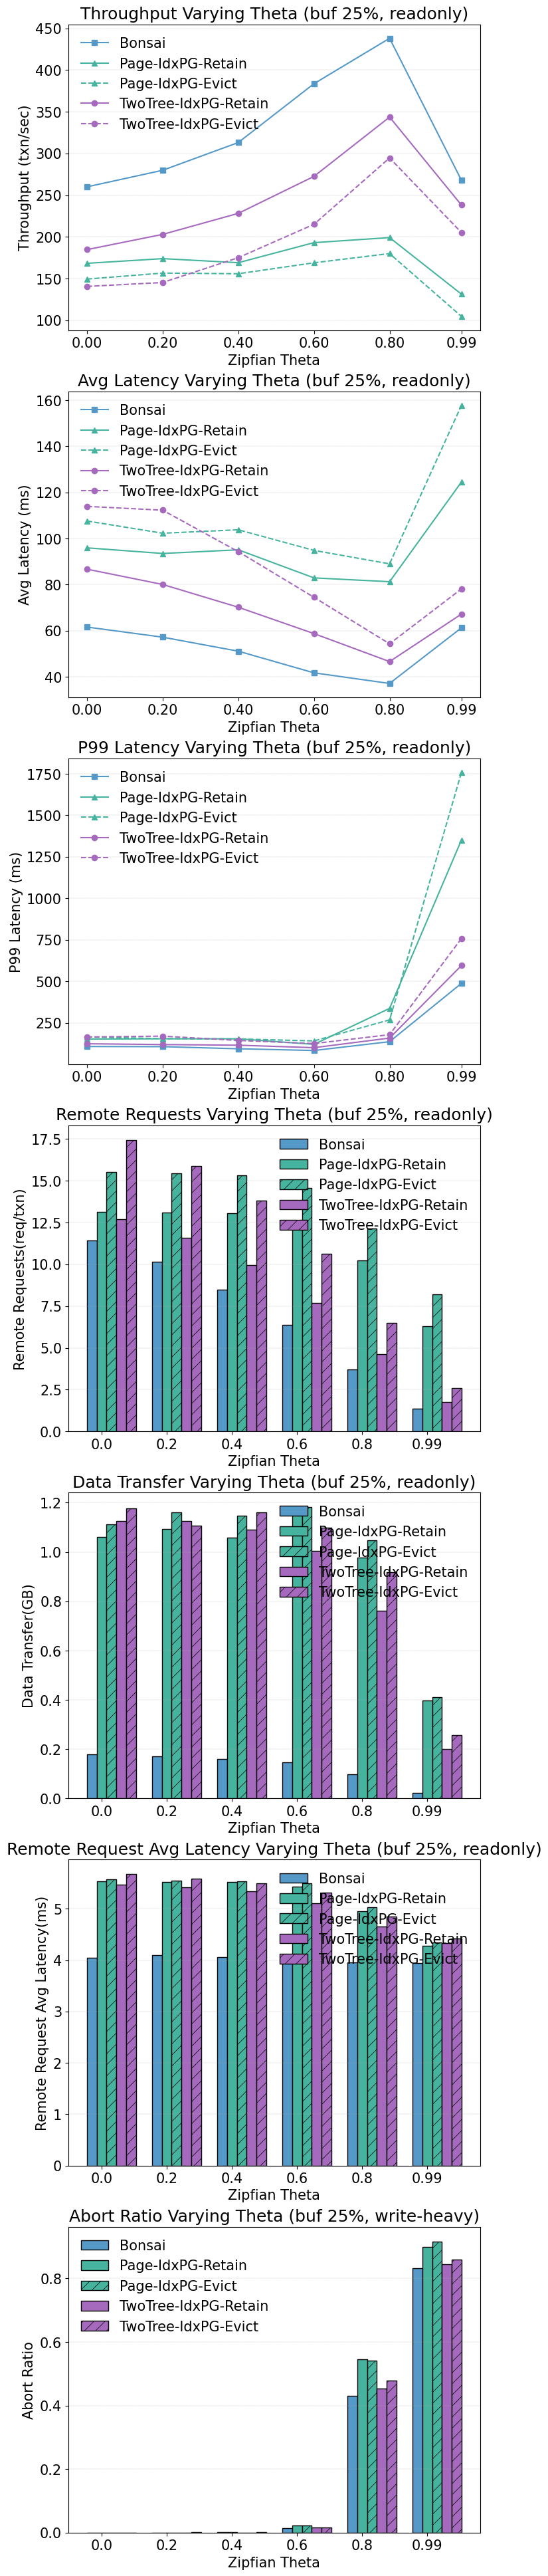

In [10]:
from process_helper import *
import numpy as np

# _, grad_colors = display_colors()
# _, bar_colors = select_color_idx(4)
color_indices, line_colors = select_color_idx(4)

plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5
idxs = ["g_total_buf_sz", "read_perc_","zipf_theta_"]
datadir = "../output/"
# exp_page = "debug_exp_point_10g_page_fanout250"
exp_page = "exp_point_10g_page_unihotspot_rw"
exp_page_idx_evict = "exp_point_10g_page_unihotspot_idx_evict_rw"
exp_tuple = "exp_point_10g_tuple_unihotspot_rw"
# exp_remote = "different_settings/" + "microbench_zipf_10g_fanout18.out"
exp_twotree = "exp_point_10g_twotree_unihotspot_rw"
exp_twotree_idx_evict = "exp_point_10g_twotree_unihotspot_idx_evict_rw"

data_page = [json.loads(line) for line in open(datadir + exp_page + ".txt")]
df_page = pd.DataFrame().from_records(data_page)
df_page = df_page.sort_values(by='zipf_theta_')


data_page_idx_evict = [json.loads(line) for line in open(datadir + exp_page_idx_evict + ".txt")]
df_page_idx_evict = pd.DataFrame().from_records(data_page_idx_evict)
df_page_idx_evict = df_page_idx_evict.sort_values(by='zipf_theta_')


data_tuple = [json.loads(line) for line in open(datadir + exp_tuple + ".txt")]
df_tuple = pd.DataFrame().from_records(data_tuple)
df_tuple = df_tuple.sort_values(by='zipf_theta_')

# # data_remote = [json.loads(line) for line in open(datadir + exp_remote)]
# # df_remote = pd.DataFrame().from_records(data_remote)
# # df_remote = apply_mask(df_remote, [
# #     ["g_buf_type", ["eq", "NOBUF"]]
# # ])

data_tt = [json.loads(line) for line in open(datadir + exp_twotree + ".txt")]
df_tt = pd.DataFrame().from_records(data_tt)
df_tt = df_tt.sort_values(by='zipf_theta_')


data_tt_idx_evict = [json.loads(line) for line in open(datadir + exp_twotree_idx_evict + ".txt")]
df_tt_idx_evict = pd.DataFrame().from_records(data_tt_idx_evict)
df_tt_idx_evict = df_tt_idx_evict.sort_values(by='zipf_theta_')


# print(df_tuple)
fig = plt.figure(figsize=(8, 49))

# fig, ax = plt.subplots()
ax = fig.add_subplot(7, 1, 1)


ax.plot(df_tuple["zipf_theta_"], 
        df_tuple["throughput_txn_per_sec"],
        color=line_colors["BLUE"],
        marker="s", label="Bonsai")


ax.plot(df_page["zipf_theta_"], 
        df_page["throughput_txn_per_sec"],
        color=line_colors["GREEN"],
        marker="^", label="Page-IdxPG-Retain")

# # Annotate each data point with its corresponding value
# for i in range(len(df_page["zipf_theta_"])):
#     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["zipf_theta_"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_page_idx_evict["zipf_theta_"], 
        df_page_idx_evict["throughput_txn_per_sec"],
        color=line_colors["GREEN"],
        marker="^", label="Page-IdxPG-Evict", linestyle='dashed')

# # Annotate each data point with its corresponding value
# for i in range(len(df_page_idx_evict["zipf_theta_"])):
#     plt.annotate(f'{df_page_idx_evict["throughput_txn_per_sec"][i]:.2f}', (df_page_idx_evict["zipf_theta_"][i], df_page_idx_evict["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

    #     ax.plot(xval, 
    #             plot_data3.loc[y]["throughput_txn_per_sec"],
    #             color=line_colors["ORANGE"],
    #             marker=".", label="Remote-Index")

ax.plot(df_tt["zipf_theta_"], 
        df_tt["throughput_txn_per_sec"],
        color=line_colors["PURPLE"],
        marker="o", label="TwoTree-IdxPG-Retain")
ax.plot(df_tt_idx_evict["zipf_theta_"], 
        df_tt_idx_evict["throughput_txn_per_sec"],
        color=line_colors["PURPLE"],
        marker="o", label="TwoTree-IdxPG-Evict",  linestyle='dashed')
# ax.set_ylim(0, max_throughput)
#ax.set_xlim(0, 1)
ax.set_xticks(df_tuple["zipf_theta_"])
location = "upper left"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Throughput (txn/sec)")
ax.set_xlabel("Zipfian Theta")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Throughput Varying Theta (buf 25%, readonly)")

ax = fig.add_subplot(7, 1, 2)


ax.plot(df_tuple["zipf_theta_"], 
        # df_tuple["txn_latency_perc99_us"]/1000,
        df_tuple["avg_sum_txn_latency (us)"]*1.0/1000,
        # df_tuple["throughput_txn_per_sec"],
        color=line_colors["BLUE"],
        marker="s", label="Bonsai")


ax.plot(df_page["zipf_theta_"], 
        # df_page["txn_latency_perc99_us"]/1000,
        df_page["avg_sum_txn_latency (us)"]*1.0/1000,
        color=line_colors["GREEN"],
        marker="^", label="Page-IdxPG-Retain")

# # Annotate each data point with its corresponding value
# for i in range(len(df_page["zipf_theta_"])):
#     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["zipf_theta_"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_page_idx_evict["zipf_theta_"], 
        # df_page_idx_evict["txn_latency_perc99_us"]/1000,
        df_page_idx_evict["avg_sum_txn_latency (us)"]*1.0/1000,
        color=line_colors["GREEN"],
        marker="^", label="Page-IdxPG-Evict", linestyle='dashed')

# # Annotate each data point with its corresponding value
# for i in range(len(df_page_idx_evict["zipf_theta_"])):
#     plt.annotate(f'{df_page_idx_evict["throughput_txn_per_sec"][i]:.2f}', (df_page_idx_evict["zipf_theta_"][i], df_page_idx_evict["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

    #     ax.plot(xval, 
    #             plot_data3.loc[y]["throughput_txn_per_sec"],
    #             color=line_colors["ORANGE"],
    #             marker=".", label="Remote-Index")

ax.plot(df_tt["zipf_theta_"], 
        # df_tt["throughput_txn_per_sec"],
       # df_tt["txn_latency_perc99_us"]/1000,
        df_tt["avg_sum_txn_latency (us)"]*1.0/1000,
        color=line_colors["PURPLE"],
        marker="o", label="TwoTree-IdxPG-Retain")
ax.plot(df_tt_idx_evict["zipf_theta_"], 
 # df_tt_idx_evict["txn_latency_perc99_us"]/1000,
        df_tt_idx_evict["avg_sum_txn_latency (us)"]*1.0/1000,
        color=line_colors["PURPLE"],
        marker="o", label="TwoTree-IdxPG-Evict",  linestyle='dashed')
# ax.set_ylim(0, max_throughput)
#ax.set_xlim(0, 1)
ax.set_xticks(df_tuple["zipf_theta_"])
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Avg Latency (ms)")
ax.set_xlabel("Zipfian Theta")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Avg Latency Varying Theta (buf 25%, readonly)")


ax = fig.add_subplot(7, 1, 3)


ax.plot(df_tuple["zipf_theta_"], 
        df_tuple["txn_latency_perc99_us"]/1000,
        # df_tuple["avg_sum_txn_latency (us)"]/1000,
        # df_tuple["throughput_txn_per_sec"],
        color=line_colors["BLUE"],
        marker="s", label="Bonsai")


ax.plot(df_page["zipf_theta_"], 
        df_page["txn_latency_perc99_us"]/1000,
        # df_page["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["GREEN"],
        marker="^", label="Page-IdxPG-Retain")

# # Annotate each data point with its corresponding value
# for i in range(len(df_page["zipf_theta_"])):
#     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["zipf_theta_"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_page_idx_evict["zipf_theta_"], 
        df_page_idx_evict["txn_latency_perc99_us"]/1000,
        # df_page_idx_evict["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["GREEN"],
        marker="^", label="Page-IdxPG-Evict", linestyle='dashed')

# # Annotate each data point with its corresponding value
# for i in range(len(df_page_idx_evict["zipf_theta_"])):
#     plt.annotate(f'{df_page_idx_evict["throughput_txn_per_sec"][i]:.2f}', (df_page_idx_evict["zipf_theta_"][i], df_page_idx_evict["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

    #     ax.plot(xval, 
    #             plot_data3.loc[y]["throughput_txn_per_sec"],
    #             color=line_colors["ORANGE"],
    #             marker=".", label="Remote-Index")

ax.plot(df_tt["zipf_theta_"], 
       df_tt["txn_latency_perc99_us"]/1000,
        # df_tt["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["PURPLE"],
        marker="o", label="TwoTree-IdxPG-Retain")
ax.plot(df_tt_idx_evict["zipf_theta_"], 
        df_tt_idx_evict["txn_latency_perc99_us"]/1000,
        # df_tt_idx_evict["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["PURPLE"],
        marker="o", label="TwoTree-IdxPG-Evict",  linestyle='dashed')
# ax.set_ylim(0, max_throughput)
#ax.set_xlim(0, 1)
ax.set_xticks(df_tuple["zipf_theta_"])
location = "upper left"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("P99 Latency (ms)")
ax.set_xlabel("Zipfian Theta")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("P99 Latency Varying Theta (buf 25%, readonly)")


index = np.arange(len(df_tuple["zipf_theta_"]))

bar_width = 0.15

# _, ax1 = plt.subplots()
ax1 = fig.add_subplot(7, 1, 4)

ax1.bar(index + 1 * bar_width, 
        df_tuple["misses_"]/df_tuple["txn_cnt_"] , bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        df_page["misses_"]/df_page["txn_cnt_"], bar_width, edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        df_page_idx_evict["misses_"]/df_page_idx_evict["txn_cnt_"], bar_width,edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        df_tt["misses_"]/df_tt["txn_cnt_"], bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        df_tt_idx_evict["misses_"]/df_tt_idx_evict["txn_cnt_"],bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Evict",hatch="//")

ax1.set_xticks(df_tuple["zipf_theta_"])
plt.xticks(index + bar_width * (5 - 1) / 2, df_tuple["zipf_theta_"])

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
# ax1.set_ylabel("Hit Ratio")
ax1.set_ylabel("Remote Requests(req/txn)")
ax1.set_xlabel("Zipfian Theta")
ax1.set_title("Remote Requests Varying Theta (buf 25%, readonly)")

#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
# fig1.set_size_inches(8, 6)
# fig.set_size_inches(8, 6)

index = np.arange(len(df_tuple["zipf_theta_"]))

bar_width = 0.15

# _, ax1 = plt.subplots()
ax1 = fig.add_subplot(7, 1, 5)

ax1.bar(index + 1 * bar_width, 
        df_tuple["misses_"]/1000000.0 , bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        df_page["misses_"]*8/1000000.0, bar_width, edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        df_page_idx_evict["misses_"]*8/1000000.0, bar_width,edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        df_tt["misses_"]*8/1000000.0, bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        df_tt_idx_evict["misses_"]*8/1000000.0,bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Evict",hatch="//")

ax1.set_xticks(df_tuple["zipf_theta_"])
plt.xticks(index + bar_width * (5 - 1) / 2, df_tuple["zipf_theta_"])

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
# ax1.set_ylabel("Hit Ratio")
ax1.set_ylabel("Data Transfer(GB)")
ax1.set_xlabel("Zipfian Theta")
ax1.set_title("Data Transfer Varying Theta (buf 25%, readonly)")

#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)

index = np.arange(len(df_tuple["zipf_theta_"]))

bar_width = 0.15

# _, ax1 = plt.subplots()
ax1 = fig.add_subplot(7, 1, 6)

ax1.bar(index + 1 * bar_width, 
        df_tuple["remote_io_time_ms"]*1.0/df_tuple["remote_rds_"], bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        df_page["remote_io_time_ms"]*1.0/df_page["remote_rds_"], bar_width, edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        df_page_idx_evict["remote_io_time_ms"]*1.0/df_page_idx_evict["remote_rds_"], bar_width,edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        df_tt["remote_io_time_ms"]*1.0/df_tt["remote_rds_"], bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        df_tt_idx_evict["remote_io_time_ms"]*1.0/df_tt_idx_evict["remote_rds_"],bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Evict",hatch="//")

ax1.set_xticks(df_tuple["zipf_theta_"])
plt.xticks(index + bar_width * (5 - 1) / 2, df_tuple["zipf_theta_"])

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
# ax1.set_ylabel("Hit Ratio")
ax1.set_ylabel("Remote Request Avg Latency(ms)")
ax1.set_xlabel("Zipfian Theta")
ax1.set_title("Remote Request Avg Latency Varying Theta (buf 25%, readonly)")

#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)

ax1 = fig.add_subplot(7, 1, 7)

ax1.bar(index + 1 * bar_width, 
        df_tuple["abort_cnt_"]*1.0/(df_tuple["abort_cnt_"] + df_tuple["txn_cnt_"]), bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        df_page["abort_cnt_"]*1.0/(df_page["abort_cnt_"] + df_page["txn_cnt_"]), bar_width, edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        df_page_idx_evict["abort_cnt_"]*1.0/(df_page_idx_evict["abort_cnt_"] + df_page_idx_evict["txn_cnt_"]), bar_width,edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        df_tt["abort_cnt_"]*1.0/(df_tt["abort_cnt_"] + df_tt["txn_cnt_"]), bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        df_tt_idx_evict["abort_cnt_"]*1.0/(df_tt_idx_evict["abort_cnt_"] + df_tt_idx_evict["txn_cnt_"]),bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Evict",hatch="//")

ax1.set_xticks(df_tuple["zipf_theta_"])
plt.xticks(index + bar_width * (5 - 1) / 2, df_tuple["zipf_theta_"])

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
# ax1.set_ylabel("Hit Ratio")
ax1.set_ylabel("Abort Ratio")
ax1.set_xlabel("Zipfian Theta")
ax1.set_title("Abort Ratio Varying Theta (buf 25%, write-heavy)")

#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)

